In dieser finalen Fusion werden die Feinstaubwerte der Sensor.Community und der Kopfklinik angehängt.
Hierzu wurden die Werte gemittelt, um synchrone Werte zu den Satellitenüberflugen zu haben und grobe Ausreißer rauszumitteln.
Die Zeitrange geht von 12:30 bis 14:30, hat also in etwa 40 Datenpunkte der Billigsensoren und zwei Datenpunkte der Kopfklinik.

In [1]:
import pandas as pd
import numpy as np

# =========================================================
# 1. Pfade definieren
# =========================================================
sensor_file = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\sensor_community__kopfklinik_may_august.csv"
master_file = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Features_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"

# Die finale Datei für das Random Forest Training
output_file = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"

# =========================================================
# 2. Feinstaubdaten laden und zeitlich filtern
# =========================================================
print("Lade Feinstaub-Messdaten...")
df_sensors = pd.read_csv(sensor_file, sep=";", decimal=",")

# Zeitstempel ins Datetime-Format umwandeln
df_sensors['Zeitstempel'] = pd.to_datetime(df_sensors['Zeitstempel'], errors='coerce')

# PM2.5 in numerische Werte umwandeln
df_sensors['PM2.5'] = df_sensors['PM2.5'].astype(str).str.replace(",", ".", regex=False)
df_sensors['PM2.5'] = pd.to_numeric(df_sensors['PM2.5'], errors='coerce')

# Datum extrahieren für den späteren Merge
df_sensors['date'] = df_sensors['Zeitstempel'].dt.strftime('%Y-%m-%d')
df_sensors['station_id'] = df_sensors['sensor_id'].astype(str).str.strip()

# --- DER WICHTIGE ZEITFILTER (12:30 bis 14:30 Uhr) ---
print("Filtere auf das Satelliten-Überflugfenster (12:30 - 14:30 Uhr)...")
# Wir extrahieren die Uhrzeit
time_series = df_sensors['Zeitstempel'].dt.time
start_time = pd.to_datetime('12:30:00').time()
end_time = pd.to_datetime('14:30:00').time()

# Nur Daten behalten, die in dieses Fenster fallen
df_filtered = df_sensors[(time_series >= start_time) & (time_series <= end_time)].copy()

# =========================================================
# 3. Aggregation (Mittelwert pro Sensor und Tag)
# =========================================================
print("Berechne den mittäglichen PM2.5 Mittelwert pro Station und Tag...")
# Gruppieren nach Datum und Station, dann den Mittelwert von PM2.5 berechnen
daily_pm25 = df_filtered.groupby(['date', 'station_id'], as_index=False)['PM2.5'].mean()

# Spalte umbenennen, damit sie im ML-Modell klar als Zielvariable erkennbar ist
daily_pm25.rename(columns={'PM2.5': 'PM25_Target'}, inplace=True)

# Kurzer Check, wie viele gültige Tage/Stationen übrig bleiben
daily_pm25 = daily_pm25.dropna(subset=['PM25_Target'])
print(f"-> {len(daily_pm25)} gültige (Tag x Station) Kombinationen generiert.")

# =========================================================
# 4. Merge mit der Master-Feature-Datei
# =========================================================
print("Füge PM2.5 Target in die Feature-Masterdatei ein...")
df_features = pd.read_csv(master_file, sep=";", decimal=",")
df_features['station_id'] = df_features['station_id'].astype(str).str.strip()

# Den Left-Merge durchführen (Wir behalten alle Zeilen der Feature-Datei und hängen PM25_Target an)
df_final = pd.merge(
    df_features,
    daily_pm25,
    on=['date', 'station_id'],
    how='inner' # Inner Merge: Behält nur Tage, an denen wir Features UND Feinstaubmessungen haben!
)

# Optional: Nullen bei NO2 noch in NaN umwandeln (wie vorhin besprochen)
if 'S5P_NO2' in df_final.columns:
    df_final.loc[df_final['S5P_NO2'] == 0.0, 'S5P_NO2'] = np.nan

# =========================================================
# 5. Speichern
# =========================================================
df_final.to_csv(output_file, index=False, sep=";", decimal=",")

print("-" * 60)
print(f"MISSION ACCOMPLISHED! Der ML-Datensatz ist bereit für das Training:\n{output_file}")
print("-" * 60)

Lade Feinstaub-Messdaten...
Filtere auf das Satelliten-Überflugfenster (12:30 - 14:30 Uhr)...
Berechne den mittäglichen PM2.5 Mittelwert pro Station und Tag...
-> 850 gültige (Tag x Station) Kombinationen generiert.
Füge PM2.5 Target in die Feature-Masterdatei ein...
------------------------------------------------------------
MISSION ACCOMPLISHED! Der ML-Datensatz ist bereit für das Training:
C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv
------------------------------------------------------------


**Zwischenschritt**
In diesem Schritt will ich nochmal schauen, wie sehr denn die Feinstaubwerte der Sensoren miteinander korrelieren. Es ist nicht von einer perfekten Korrelation auszugehene, da die intraurbanen Unterschiede vorhanden sind und es ja auch das Ziel dieser Analyse ist, die verschiedenen Werte herauszufinden, aber es eine Großwetterlage sollte trotzdem die Sensoren in eine ähnliche Richtung beeinflussen.

Lade Masterdatensatz für die Qualitätsprüfung...
Datenstruktur erstellt. Anzahl gemeinsamer Messtage im Zeitraum: 123


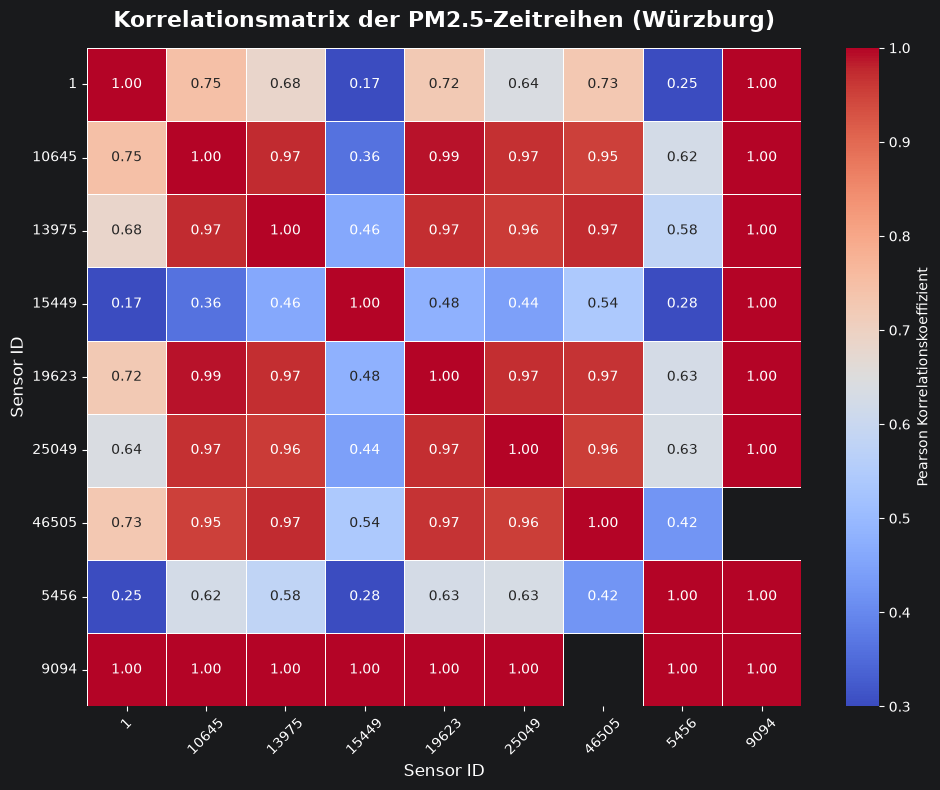

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. Pfad zur Masterdatei
# =========================================================
file_path = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"

# =========================================================
# 2. Daten laden und vorbereiten
# =========================================================
print("Lade Masterdatensatz für die Qualitätsprüfung...")
df = pd.read_csv(file_path, sep=";", decimal=",")

# Sicherstellen, dass die station_id ein sauberer Text ist (für die Achsenbeschriftung)
df['station_id'] = df['station_id'].astype(str).str.strip()

# =========================================================
# 3. Datensatz umstrukturieren (Pivot)
# =========================================================
# Um eine Korrelation zu berechnen, brauchen wir eine Tabelle, in der:
# - Jede Zeile = 1 Tag
# - Jede Spalte = 1 Sensor
# - Die Werte = PM25_Target
df_pivot = df.pivot_table(index='date', columns='station_id', values='PM25_Target')

print(f"Datenstruktur erstellt. Anzahl gemeinsamer Messtage im Zeitraum: {len(df_pivot)}")

# =========================================================
# 4. Korrelationsmatrix berechnen (Pearson-Korrelation)
# =========================================================
corr_matrix = df_pivot.corr()

# =========================================================
# 5. Visuelle Darstellung (Heatmap)
# =========================================================
plt.figure(figsize=(10, 8))

# Wir nutzen Seaborn für eine hübsche Heatmap
sns.heatmap(corr_matrix,
            annot=True,            # Schreibt die genauen Korrelationswerte in die Boxen
            cmap='coolwarm',       # Farbschema (Kalt zu Warm)
            fmt=".2f",             # Zwei Nachkommastellen (z.B. 0.85)
            vmin=0.3, vmax=1.0,    # Setzt die Farbskala (PM2.5 korreliert meist positiv > 0.3)
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Korrelationskoeffizient'})

# Plot-Styling
plt.title("Korrelationsmatrix der PM2.5-Zeitreihen (Würzburg)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Sensor ID", fontsize=12)
plt.ylabel("Sensor ID", fontsize=12)

# Beschriftungen rotieren, damit sie gut lesbar sind
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Ohne 5456 und 15449**

Lade Masterdatensatz für die Qualitätsprüfung...
Sensoren ['5456', '15449', '9094'] wurden für diese Analyse erfolgreich entfernt.
Datenstruktur erstellt. Anzahl gemeinsamer Messtage im Zeitraum: 123


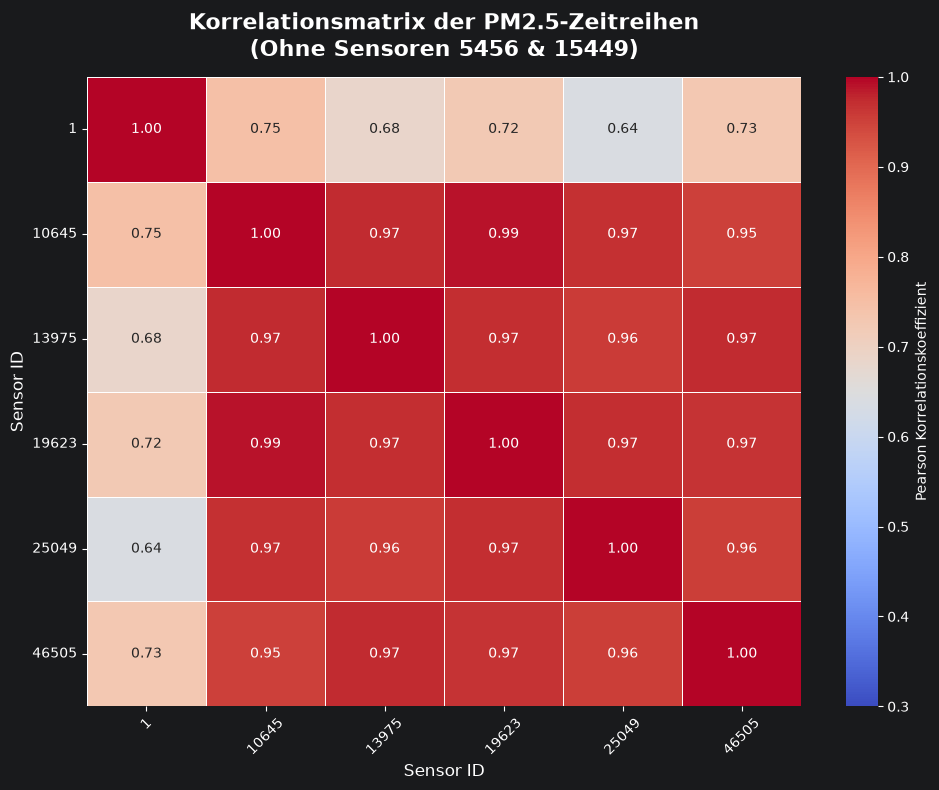

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. Pfad zur Masterdatei
# =========================================================
file_path = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"

# =========================================================
# 2. Daten laden und vorbereiten
# =========================================================
print("Lade Masterdatensatz für die Qualitätsprüfung...")
df = pd.read_csv(file_path, sep=";", decimal=",")

# Sicherstellen, dass die station_id ein sauberer Text ist
df['station_id'] = df['station_id'].astype(str).str.strip()

# --- NEU: Bestimmte Sensoren (Ausreißer) ausschließen ---
sensoren_zu_entfernen = ['5456', '15449','9094']
df = df[~df['station_id'].isin(sensoren_zu_entfernen)]
print(f"Sensoren {sensoren_zu_entfernen} wurden für diese Analyse erfolgreich entfernt.")

# =========================================================
# 3. Datensatz umstrukturieren (Pivot)
# =========================================================
# Um eine Korrelation zu berechnen, brauchen wir eine Tabelle: Zeilen=Tage, Spalten=Sensoren
df_pivot = df.pivot_table(index='date', columns='station_id', values='PM25_Target')

print(f"Datenstruktur erstellt. Anzahl gemeinsamer Messtage im Zeitraum: {len(df_pivot)}")

# =========================================================
# 4. Korrelationsmatrix berechnen (Pearson-Korrelation)
# =========================================================
corr_matrix = df_pivot.corr()

# =========================================================
# 5. Visuelle Darstellung (Heatmap)
# =========================================================
plt.figure(figsize=(10, 8))

# Seaborn Heatmap plotten
sns.heatmap(corr_matrix,
            annot=True,            # Schreibt die genauen Korrelationswerte in die Boxen
            cmap='coolwarm',       # Farbschema (Kalt zu Warm)
            fmt=".2f",             # Zwei Nachkommastellen (z.B. 0.85)
            vmin=0.3, vmax=1.0,    # Setzt die Farbskala
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Korrelationskoeffizient'})

# Plot-Styling
plt.title("Korrelationsmatrix der PM2.5-Zeitreihen\n(Ohne Sensoren 5456 & 15449)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Sensor ID", fontsize=12)
plt.ylabel("Sensor ID", fontsize=12)

# Beschriftungen rotieren, damit sie gut lesbar sind
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Hier unten mit dem Offset von 4,88. Macht aber für die Pearson-Korrelation keinen Unterschied.

Lade Masterdatensatz für die Qualitätsprüfung...
Sensoren ['5456', '15449', '9094'] wurden für diese Analyse erfolgreich entfernt.
Führe Baseline-Kalibrierung durch: +4.88 µg/m³ für alle Low-Cost-Sensoren...
Datenstruktur erstellt. Anzahl gemeinsamer Messtage im Zeitraum: 123


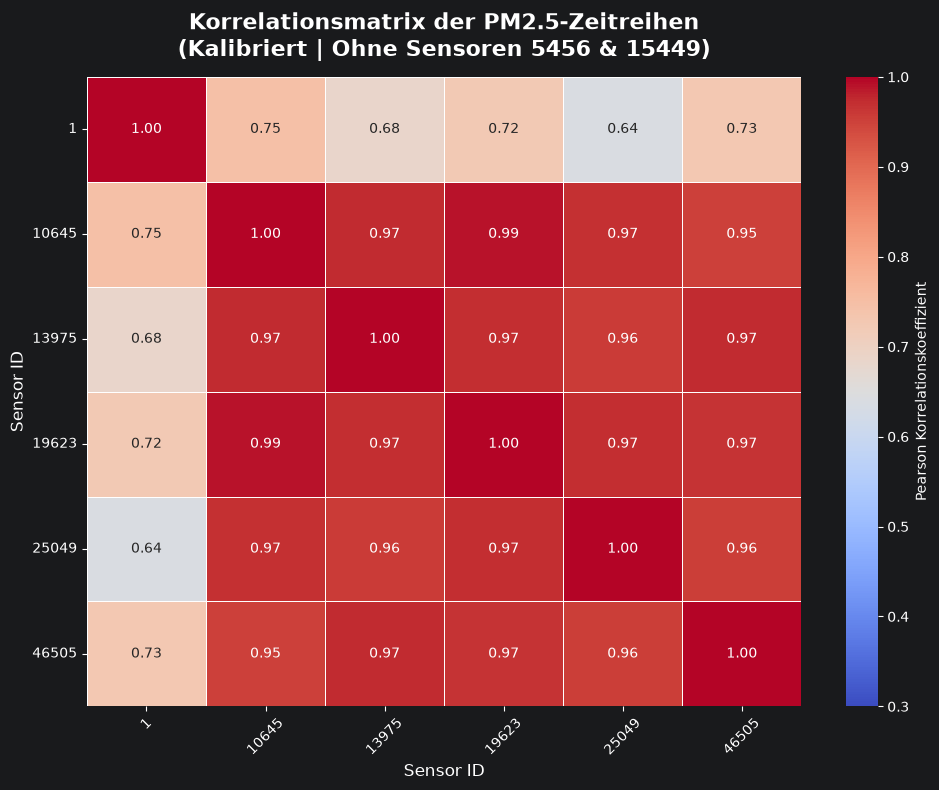

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. Pfad zur Masterdatei
# =========================================================
file_path = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output\Features_RH_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv"

# =========================================================
# 2. Daten laden und vorbereiten
# =========================================================
print("Lade Masterdatensatz für die Qualitätsprüfung...")
df = pd.read_csv(file_path, sep=";", decimal=",")

# Sicherstellen, dass die station_id ein sauberer Text ist
df['station_id'] = df['station_id'].astype(str).str.strip()

# --- Bestimmte Sensoren (Ausreißer) ausschließen ---
sensoren_zu_entfernen = ['5456', '15449', '9094']
df = df[~df['station_id'].isin(sensoren_zu_entfernen)]
print(f"Sensoren {sensoren_zu_entfernen} wurden für diese Analyse erfolgreich entfernt.")

# =========================================================
# 3. Hardware-Kalibrierung (Offset anwenden)
# =========================================================
offset = 4.88
print(f"Führe Baseline-Kalibrierung durch: +{offset} µg/m³ für alle Low-Cost-Sensoren...")

# Erhöhe alle Werte, bei denen die ID NICHT "1" (Kopfklinik) ist
df.loc[df['station_id'] != "1", 'PM25_Target'] += offset

# =========================================================
# 4. Datensatz umstrukturieren (Pivot)
# =========================================================
# Um eine Korrelation zu berechnen, brauchen wir eine Tabelle: Zeilen=Tage, Spalten=Sensoren
df_pivot = df.pivot_table(index='date', columns='station_id', values='PM25_Target')

print(f"Datenstruktur erstellt. Anzahl gemeinsamer Messtage im Zeitraum: {len(df_pivot)}")

# =========================================================
# 5. Korrelationsmatrix berechnen (Pearson-Korrelation)
# =========================================================
corr_matrix = df_pivot.corr()

# =========================================================
# 6. Visuelle Darstellung (Heatmap)
# =========================================================
plt.figure(figsize=(10, 8))

# Seaborn Heatmap plotten
sns.heatmap(corr_matrix,
            annot=True,            # Schreibt die genauen Korrelationswerte in die Boxen
            cmap='coolwarm',       # Farbschema (Kalt zu Warm)
            fmt=".2f",             # Zwei Nachkommastellen (z.B. 0.85)
            vmin=0.3, vmax=1.0,    # Setzt die Farbskala
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Korrelationskoeffizient'})

# Plot-Styling
plt.title("Korrelationsmatrix der PM2.5-Zeitreihen\n(Kalibriert | Ohne Sensoren 5456 & 15449)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Sensor ID", fontsize=12)
plt.ylabel("Sensor ID", fontsize=12)

# Beschriftungen rotieren, damit sie gut lesbar sind
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()